# ESM3 Protein Embeddings for Downstream Tasks

This notebook demonstrates how to leverage ESM3 embeddings for biological sequence analysis. ESM3 is a transformer-based protein language model trained on large-scale evolutionary data and captures rich structural and functional signals from raw amino acid sequences.

We explore two main case studies:

-  **Contextual Embeddings**: how unsupervised ESM3 representations reflect function and taxonomy.
-  **Druggability Prediction**: using ESM3 embeddings in a supervised learning task.

## Contextual Embeddings

### Functional Separation (Sanity Check)

We begin with a simple visualization to demonstrate that proteins with different functions tend to be **spatially separated** in ESM3’s embedding space, even without any fine-tuning.

To that end, we select two functionally distinct groups of proteins:

-  Transport/Oxygen-related Proteins (e.g., hemoglobin, myoglobin): These proteins are involved in oxygen transport or exchange. They are structurally conserved and well-characterized.
-  Blood Glucose and Calcium Regulation Proteins (e.g., insulin, glucagon, calcium-binding proteins): These proteins are involved in metabolic signaling and ion homeostasis, and represent a very different biological role.

These two groups were deliberately chosen to be biologically distinct in function and mechanism. If the ESM3 model encodes meaningful biological structure, we would expect that:

-  Proteins within each group will form coherent clusters.
-  The two groups will be well-separated in a low-dimensional projection (e.g., via t-SNE), despite no training or supervision.

This example serves as a sanity check for the expressiveness of ESM3 embeddings with respect to **protein function**.

We will:

-  Generate embeddings for each sequence using ESM3.
-  Use t-SNE to reduce them to 2D.
-  Visualize the result with clear group annotations.

In [1]:
# Define the new protein dataset with similar and opposite functions
proteins = {
    'Transport/Oxygen-related Proteins': [
        'MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHSKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFK',  # Hemoglobin Alpha Chain (HBA)
        'MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH',  # Hemoglobin Beta Chain (HBB)
        'MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG'  # Myoglobin (MB)
    ],
    'Blood Glucose and Calcium Regulation Proteins': [
        'MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN',  # Insulin (INS)
        'MKSIYFVAGLFVMLVQGSWQRSLQDTEEKSRSFSASQADPLSDPDQMNEDKRHSQGTFTSDYSKYLDSRRAQDFVQWLMNTKRNRNNIAKRHDEFERHAEGTFTSDVSSYLEGQAAKEFIAWLVKGRGRRDFPEEVAIVEELGRRHADGSFSDEMNTILDNLAARDFINWLIQTKITDRK',  # Glucagon (GCG)
        'MIPAKDMAKVMIVMLAICFLTKSDGKSVKKRSVSEIQLMHNLGKHLNSMERVEWLRKKLQDVHNFVALGAPLAPRDAGSQRPRKKEDNVLVESHEKSLGEADKADVNVLTKAKSQ',  # Parathyroid Hormone (PTH)
        'MGFQKFSPFLALSILVLLQAGSLHAAPFRSALESSPADPATLSEDEARLLLAALVQDYVQMKASELEQEQEREGSRIIAQKRACDTATCVTHRLAGLLSRSGGVVKNNFVPTNVGSKAFGRRRRDLQA',  # Calcitonin (CALCA)
    ],
    'labels': [
        'HBA', 'HBB', 'MB',
        'INS', 'GCG', 'PTH', 'CALCA'  
    ],
    'colors': ['red', 'green']
}

# Prepare data
sequences = proteins['Transport/Oxygen-related Proteins'] + proteins['Blood Glucose and Calcium Regulation Proteins']
labels = proteins['labels']
function_labels = ['Transport/Oxygen-related Proteins'] * len(proteins['Transport/Oxygen-related Proteins']) + ['Blood Glucose and Calcium Regulation Proteins'] * len(proteins['Blood Glucose and Calcium Regulation Proteins'])
colors = ['green'] * len(proteins['Transport/Oxygen-related Proteins']) + ['red'] * len(proteins['Blood Glucose and Calcium Regulation Proteins'])

In [2]:
from src import ESM3EmbeddingGenerator, embeddings_to_matrix

print("Initializing ESM3 model...")
embedding_generator = ESM3EmbeddingGenerator(login_required=False)

print("Generating embeddings...")
embeddings_list = embedding_generator.generate_embeddings(sequences)
embeddings_matrix = embeddings_to_matrix(embeddings_list)

print(f"Embeddings shape: {embeddings_matrix.shape}")

Initializing ESM3 model...
Generating embeddings...


Generating embeddings: 100%|██████████| 7/7 [00:08<00:00,  1.20s/it]

Embeddings shape: (7, 1536)


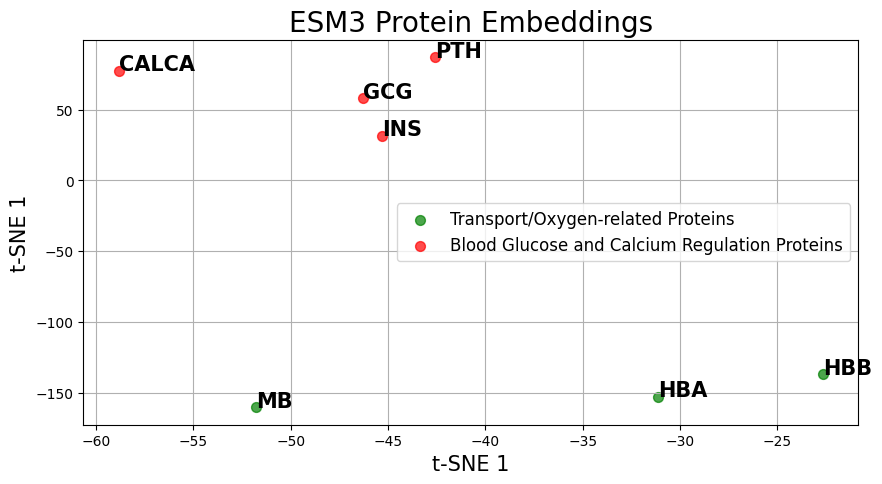

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Dimensionality Reduction using t-SNE
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_matrix)

# Visualize the embeddings with labels
plt.figure(figsize=(10, 5))

# Plot similar function proteins
transport_idxs = [i for i, func in enumerate(function_labels) if func == 'Transport/Oxygen-related Proteins']
plt.scatter(embeddings_2d[transport_idxs, 0], embeddings_2d[transport_idxs, 1], c='green', label='Transport/Oxygen-related Proteins', alpha=0.7, s=50)

# Plot antagonistic function proteins
regulation_idxs = [i for i, func in enumerate(function_labels) if func == 'Blood Glucose and Calcium Regulation Proteins']
plt.scatter(embeddings_2d[regulation_idxs, 0], embeddings_2d[regulation_idxs, 1], c='red', label='Blood Glucose and Calcium Regulation Proteins', alpha=0.7, s=50)

# Annotate each point with the corresponding label
for i, label in enumerate(labels):
    plt.text(embeddings_2d[i, 0], embeddings_2d[i, 1], label, fontsize=15, fontweight='bold')

plt.title('ESM3 Protein Embeddings', fontsize=20)
plt.xlabel('t-SNE 1', fontsize=15)
plt.ylabel('t-SNE 1', fontsize=15)
plt.legend(fontsize=12, loc='center right')
plt.grid(True)
plt.show()

This visualization confirms our expectations:
**ESM3 embeddings separate functionally distinct proteins even without supervision.**

-  The oxygen transport proteins (MB, HBA, HBB) form a tight cluster in the lower half of the plot.
-  The regulatory proteins involved in blood glucose and calcium homeostasis (INS, GCG, PTH, CALCA) cluster separately, well above and to the left.

Despite being a small and simple example, this result highlights the biological relevance of ESM3's embedding space: it encodes signals that reflect protein function without any task-specific training.

## Taxonomic Clustering by Kingdom

Next, we extend this analysis by visualizing ESM3 embeddings from a random subset of the UniRef50 dataset, annotated with known taxonomic labels.

-  Each sequence belongs to one of three kingdoms: Bacteria, Archaea, or Eukaryota.
-  We embed each sequence using ESM3.
-  We visualize the low-dimensional representation and train a simple classifier to quantify how well taxonomy is separated.

Our goal is to examine whether these high-level evolutionary groupings are reflected in the embedding space learned by ESM3.

### Zero-Shot Visualization

First, we compute ESM3 embeddings for each protein sequence without any task-specific training or fine-tuning, and reduce the dimensionality using t-SNE.

We expect that proteins from the same kingdom will cluster together in the latent space, indicating that ESM3 has implicitly learned evolutionary distinctions during pretraining.

Let's inspect the raw data.

In [4]:
import pandas as pd

uni_ref_50 = pd.read_csv('data/kingdom_classification/uniref_50_processed_3k.csv')
uni_ref_50.head()

,Tax,TaxID,sequence
0,Chloroflexi,2026724,MSSMYPPSSGPLLQRCIRCGIPLPPNVSMCGNCGTFNTLQQSGGFM...
1,Burkholderia,1503054,MRFELCFRFVALLSRERSQGAGREGQQNGDLGVMVGLSIFEFAQLL...
2,Dendrobium,94219,MIGDFRGNFALLSSSITVTSLPFFPRSDSGRILKTYADHFLNASLA...
3,Eisenbergiella,1720294,MVTAWDACTTALSVLYHRIAGSAKKNGGKGKRIVTVLTDKPFTMNV...
4,Amycolatopsis,218823,MSLPSASFRDLAAAQGFPAEDVERWAALARPCARLAPDGDGPVAGR...


Each protein in the UniRef50 subset is associated with a NCBI Taxonomy ID (TaxID). To assign a kingdom label, we used the [ETE Toolkit](https://etetoolkit.org/) to retrieve the taxonomic lineage for each TaxID.

We then mapped each sequence to one of the following kingdoms: Bacteria, archaea, eukaryota.

This is done by traversing the taxonomic lineage and checking for the presence of these top-level categories. Sequences not belonging to any of these three groups were marked as "unclassified" and excluded from the analysis.

In [5]:
from src.data_processing import map_taxid_to_kingdom

# Apply the function to the 'TaxID' column
uni_ref_50['Label'] = uni_ref_50['TaxID'].apply(map_taxid_to_kingdom)
uni_ref_50 = uni_ref_50[uni_ref_50['Label'] != 'unclassified']

# Display the resulting DataFrame
print(uni_ref_50.head())

              Tax    TaxID                                           sequence  \
0     Chloroflexi  2026724  MSSMYPPSSGPLLQRCIRCGIPLPPNVSMCGNCGTFNTLQQSGGFM...   
1    Burkholderia  1503054  MRFELCFRFVALLSRERSQGAGREGQQNGDLGVMVGLSIFEFAQLL...   
2      Dendrobium    94219  MIGDFRGNFALLSSSITVTSLPFFPRSDSGRILKTYADHFLNASLA...   
3  Eisenbergiella  1720294  MVTAWDACTTALSVLYHRIAGSAKKNGGKGKRIVTVLTDKPFTMNV...   
4   Amycolatopsis   218823  MSLPSASFRDLAAAQGFPAEDVERWAALARPCARLAPDGDGPVAGR...   

       Label  
0   bacteria  
1   bacteria  
2  eukaryota  
3   bacteria  
4   bacteria  


Let's inspect the distribution of the kingdoms in the dataset.

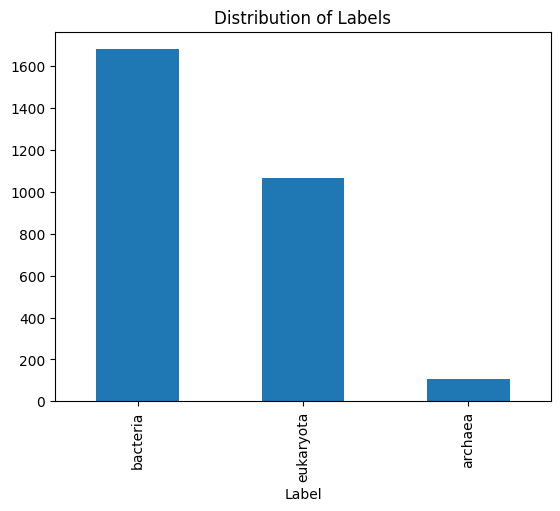

In [6]:
uni_ref_50['Label'].value_counts().plot(kind='bar', title='Distribution of Labels')
plt.show()

This label distribution shows a clear class imbalance in the dataset:

-  Bacteria dominate the sample set with over 1600 sequences.
-  Eukaryota are moderately represented with ~1100 sequences.
-  Archaea are significantly underrepresented, with fewer than 150 entries.

This imbalance should be taken into account when interpreting both the zero-shot clustering and the performance of the MLP classifier, particularly for archaea, where limited representation may affect generalization.

Let's generate the embeddings of the primary sequences and plot their lower dimensional projections with t-SNE.

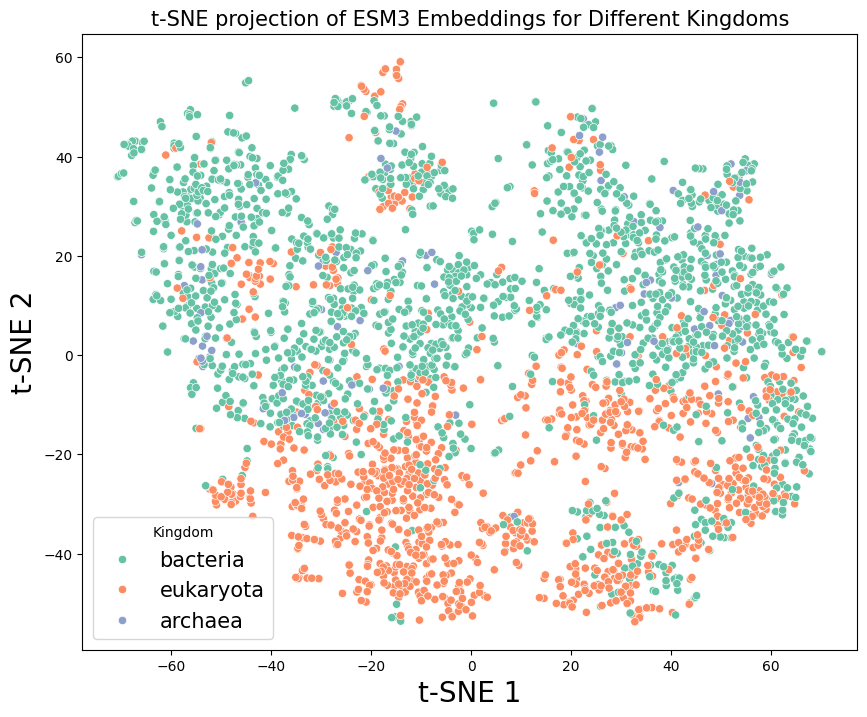

In [7]:
import seaborn as sns
import numpy as np
# print("Generating embeddings...")
# embeddings_list = embedding_generator.generate_embeddings(uni_ref_50['sequence'].tolist())
# embeddings_matrix = embeddings_to_matrix(embeddings_list)

embeddings = pd.read_csv('data/kingdom_classification/embeddings_uni_ref_50_kingdom_labelled.csv').to_numpy()

# Seperate features and labels
X = embeddings[:, :-1].astype(np.float32)
labels = embeddings[:, -1]

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=3000, random_state=42)
embeddings_2d = tsne.fit_transform(X)

# Create a DataFrame for plotting
df = pd.DataFrame({'x': embeddings_2d[:, 0], 'y': embeddings_2d[:, 1], 'Label': labels})
# Plotting the 2D projections
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x', y='y', hue='Label', data=df, palette='Set2')
plt.title("t-SNE projection of ESM3 Embeddings for Different Kingdoms", fontsize=15)
plt.xlabel("t-SNE 1", fontsize=20)
plt.ylabel("t-SNE 2", fontsize=20)
plt.legend(title='Kingdom',fontsize=15)
plt.show()

This zero-shot t-SNE visualization demonstrates that ESM3 embeddings capture evolutionary signals without any explicit supervision:

- Bacterial and eukaryotic sequences form visibly distinct clusters, indicating that ESM3 encodes taxonomic structure at the representation level.
- Archaeal sequences, although fewer in number, tend to overlap more with bacterial regions, which may reflect shared prokaryotic characteristics, despite distinct evolutionary lineages.
- The fact that this structure emerges purely from the pretrained model (no fine-tuning, no labels used during embedding) showcases the biological priors learned by ESM3.

Overall, this plot confirms that ESM3 embeddings are not just context-aware at the sequence level, but also reflect deep evolutionary hierarchies learned from large-scale pretraining.

### Supervised Classification

Next, we train a simple multi-layer perceptron (MLP) classifier using the frozen ESM3 embeddings as input features. Specifically, the ESM3 model is not fine-tuned, we only train the classification head. This lets us test how well the embeddings support downstream learning with minimal supervision.

Training Kingdom Classification Model...
Label mapping: {'archaea': 0, 'bacteria': 1, 'eukaryota': 2}


Training:   1%|          | 1/100 [00:00<00:11,  8.35it/s]

Epoch 0: Train Loss: 0.8658, Train Acc: 61.46%, Val Loss: 0.5635, Val Acc: 81.64%


Training:  13%|█▎        | 13/100 [00:00<00:04, 21.64it/s]

Epoch 10: Train Loss: 0.3256, Train Acc: 88.58%, Val Loss: 0.3393, Val Acc: 88.46%


...

Epoch 30: Train Loss: 0.2055, Train Acc: 92.08%, Val Loss: 0.3817, Val Acc: 87.59%


Training:  43%|████▎     | 43/100 [00:02<00:03, 17.15it/s]

Epoch 40: Train Loss: 0.1635, Train Acc: 93.88%, Val Loss: 0.4186, Val Acc: 87.41%


Training:  45%|████▌     | 45/100 [00:02<00:02, 20.08it/s]


Early stopping at epoch 45


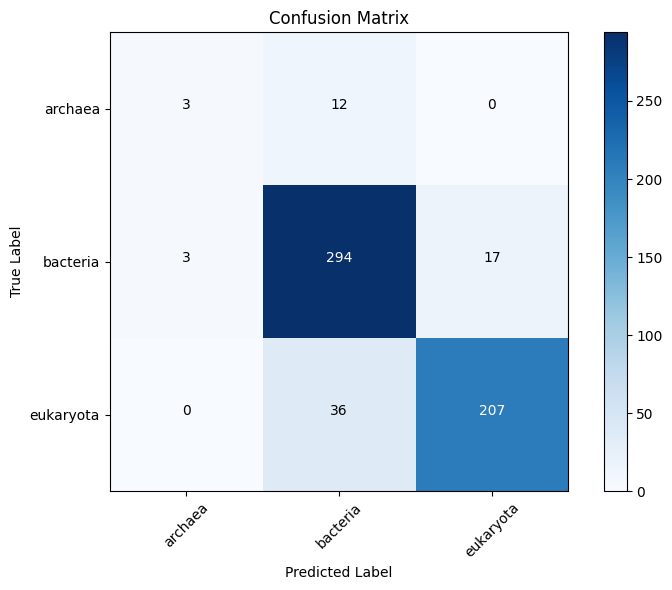


Kingdom Classification Results:
Final Test Accuracy: 0.8811
Final Test F1 Score: 0.8762
Final Test AUC: 0.9453


In [8]:
from src.classification import KingdomClassifier

kingdom_clf = KingdomClassifier(hidden_layers=[128, 64], dropout_rate=0.3)
metrics = kingdom_clf.train(
    embeddings=X,
    labels=labels,
    test_size=0.2,
    epochs=100
)

The MLP classifier, trained on frozen ESM3 embeddings, performs well overall.

The confusion matrix shows that:

- Bacteria and Eukaryota are classified with high precision and recall, despite some mutual confusion.
- Most misclassifications of Eukaryota are predicted as Bacteria, suggesting some overlap in the embedding space, possibly due to shared protein domains or convergent functional elements.
- Archaea, being underrepresented in the dataset, show higher classification error and some confusion with Bacteria, which may reflect both the data imbalance and overlapping prokaryotic features captured by ESM3.

Overall, the results confirm that ESM3 embeddings encode taxonomic distinctions that are learnable even with a simple linear classifier, and without fine-tuning the model.

# Druggability Prediction

In this case study, we explore whether ESM3 embeddings can be used to predict the druggability of proteins, i.e., their likelihood of being viable therapeutic targets.

We use the dataset developed by [Jamali et al](https://pubmed.ncbi.nlm.nih.gov/26821132/), which serves as a benchmark for this task.


We use the [Jamali et al](https://pubmed.ncbi.nlm.nih.gov/26821132/) dataset, a benchmark curated dataset for binary classification of druggable vs non-druggable protein targets. It was constructed as follows:

-  Druggable targets were collected from DrugBank, a widely used database of FDA-approved and experimental drug targets.
-  Non-druggable targets were carefully curated by excluding all known drug targets and their homologous families across Swiss-Prot, DrugBank, and the Therapeutic Target Database (TTD).

This curation ensures that non-druggable sequences do not simply mirror known drug targets, making the classification task more realistic and biologically meaningful. 

As before, we will first do a zero-shot visualization and then train an MLP classifier head on top of the frozen ESM3 embeddings.

## Exploratory Data Analysis

Let's first convert the FASTA files to CSV, add labels and do some exploatory data analysis (EDA).


In [9]:
from src.data_processing import process_fasta_file

# # Process each FASTA file with appropriate druggable value
# positive_train_df = process_fasta_file('data/drug_miner/positive_train_sequence.fasta', druggable_value=1)
# negative_train_df = process_fasta_file('data/drug_miner/negative_train_sequence.fasta', druggable_value=0)
# positive_test_df = process_fasta_file('data/drug_miner/positive_test_sequence.fasta', druggable_value=1)
# negative_test_df = process_fasta_file('data/drug_miner/negative_test_sequence.fasta', druggable_value=0)

# Combine the dataframes
train_df = pd.read_csv('data/drug_miner/training_set.csv')
test_df = pd.read_csv('data/drug_miner/test_set.csv')

# Shuffle the training and test sets
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first few rows of the combined dataframe
print(train_df.head())


  Accession   Description                                           Sequence  \
0    P62854    RS26_HUMAN  MTKKRRNNGRAKKGRGHVQPIRCTNCARCVPKDKAIKKFVIRNIVE...   
1    O67135  O67135_AQUAE  MKKVKLIGTLDYGKYRYPKNHPLKIPRVSLLLRFLDAMNLIDEKEL...   
2    P45877    PPIC_HUMAN  MGPGPRLLLPLVLCVGLGALVFSSGAEGFRKRGPSVTAKVFFDVRI...   
3       NaN           NaN  MWSRLVWLGLRAPLGGRQGFTSKADPQGSGRITAAVIEHLERLALV...   
4    P23434    GCSH_HUMAN  MALRVVRSVRALLCTLRAVPSPAAPCPPRPWQLGVGAVRTLRTGPA...   

   Druggable  
0          0  
1          1  
2          1  
3          0  
4          0  


#### Human vs Non-Human Proteins

Before evaluating model performance, it's important to understand the biological composition of the dataset. In particular, we examine the proportion of human versus non-human proteins in both the training and test sets.

This is relevant because many protein language models, including ESM3, are trained on diverse datasets, but downstream applications (like drug discovery) often emphasize human proteins. A skew in species distribution can influence both model behavior and generalization.

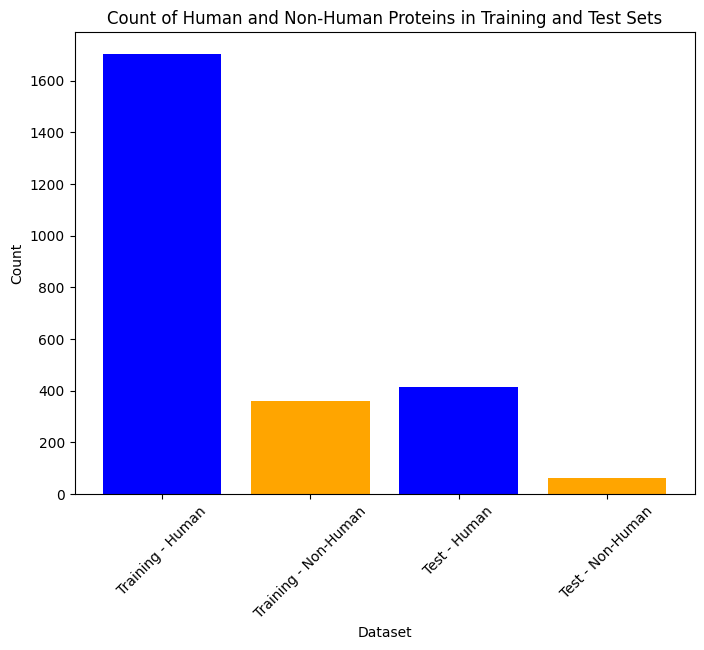

In [10]:
from src.data_processing import add_human_classification

train_df = add_human_classification(train_df)
test_df = add_human_classification(test_df)

# Count the number of human and non-human proteins in both datasets
train_counts = train_df['Is_Human'].value_counts()
test_counts = test_df['Is_Human'].value_counts()

# Convert counts to DataFrame for easier plotting
count_df = pd.DataFrame({
    'Set': ['Training', 'Training', 'Test', 'Test'],
    'Is_Human': ['Human', 'Non-Human', 'Human', 'Non-Human'],
    'Count': [train_counts.get(True, 0), train_counts.get(False, 0), test_counts.get(True, 0), test_counts.get(False, 0)]
})

# Plot the bar plot
plt.figure(figsize=(8, 6))
plt.bar(count_df['Set'] + ' - ' + count_df['Is_Human'], count_df['Count'], color=['blue', 'orange'])
plt.title('Count of Human and Non-Human Proteins in Training and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The dataset is heavily skewed toward human proteins, which is expected in drug discovery applications. While this may introduce human-specific biases during training and limit generalization to non-human proteins, ESM3's pretraining on evolutionarily diverse sequences helps mitigate this risk. This analysis provides important context for interpreting model performance across species if needed.

#### Class Balance in Training and Test Sets

Let's also check whether the training and test sets are balanced.

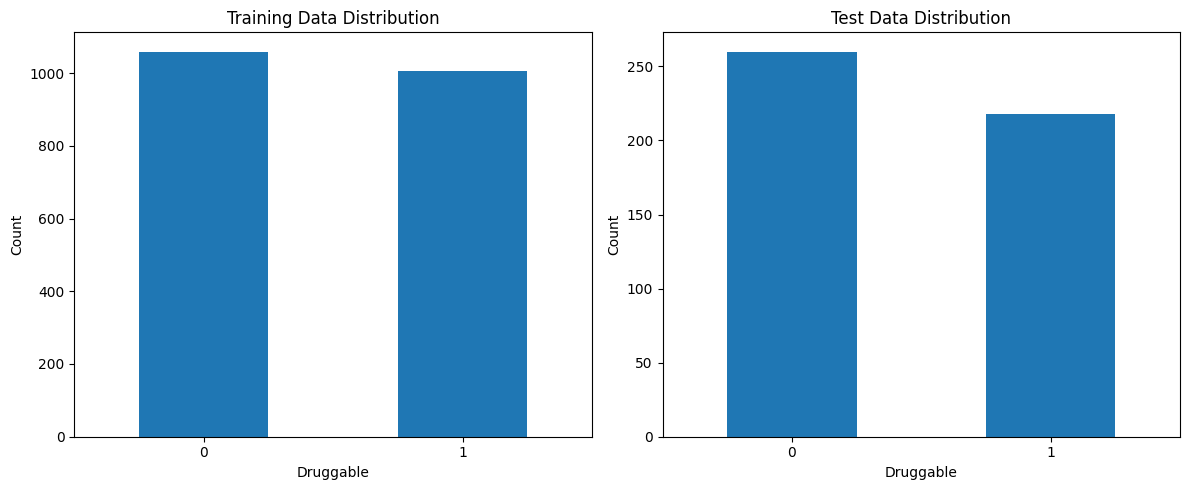

In [11]:
# Using pandas subplot functionality
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train_df['Druggable'].value_counts().plot(kind='bar', ax=axes[0], title='Training Data Distribution')
test_df['Druggable'].value_counts().plot(kind='bar', ax=axes[1], title='Test Data Distribution')

# Set common labels
for ax in axes:
    ax.set_xlabel('Druggable')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The class distribution is reasonably balanced in both training and test sets:

- The training set contains a nearly equal number of druggable (1) and non-druggable (0) proteins.
- The test set shows a slight skew toward non-druggable proteins, but the difference is not severe.

This balance is important for ensuring that classification metrics like accuracy, F1 score, and AUC are reliable and not biased by class prevalence. There’s no immediate need for reweighting or resampling, and the dataset is well-suited for training a binary classifier.

#### Inspecting Sequence Lengths

Since the ESM3 model has a maximum context length (and memory usage scales quadratically with sequence length), we apply a truncation threshold of 1800 residues during embedding.

This is primarily a practical constraint to avoid GPU memory issues, sequences longer than 1800 residues are truncated from the end.

To assess the impact of this truncation, we examine the distribution of sequence lengths across the training and test sets.

- If most sequences are shorter than 1800, we retain the full sequence context for those inputs.
- If many sequences exceed this threshold, truncation could potentially remove important C-terminal information, affecting downstream performance.

By visualizing sequence lengths, we can understand whether truncation was a safe preprocessing step or a potential limitation in our pipeline.

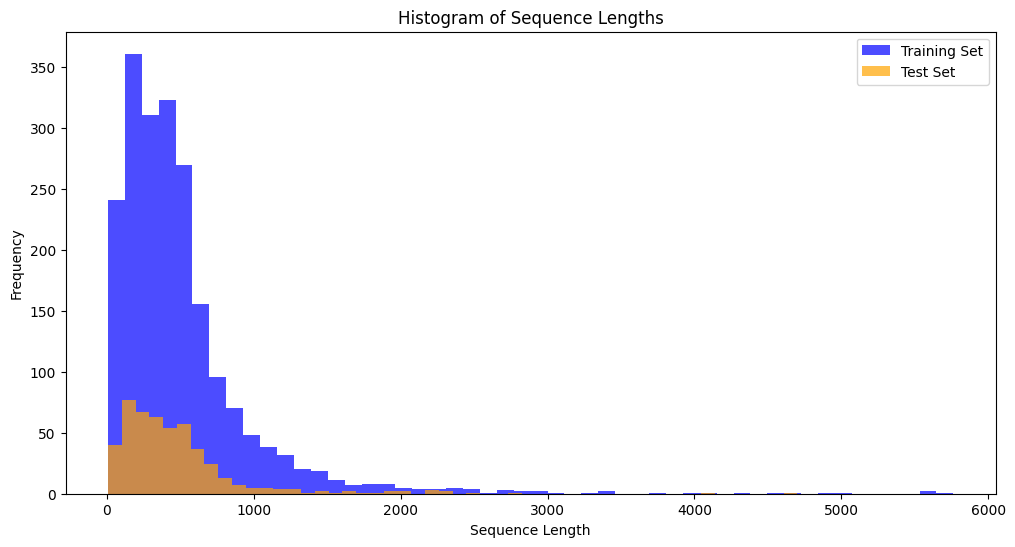

In [12]:
# Calculate sequence lengths for both sets
train_df['Sequence_Length'] = train_df['Sequence'].apply(len)
test_df['Sequence_Length'] = test_df['Sequence'].apply(len)

# Plot histogram for sequence lengths in training set
plt.figure(figsize=(12, 6))
plt.hist(train_df['Sequence_Length'], bins=50, alpha=0.7, label='Training Set', color='blue')
plt.hist(test_df['Sequence_Length'], bins=50, alpha=0.7, label='Test Set', color='orange')
plt.title('Histogram of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

The majority of sequences in the dataset are well below the 1800-residue truncation threshold, with a sharp drop-off beyond ~1000 residues. This suggests that for most proteins, the full sequence context is preserved during embedding.

This distribution validates our decision to truncate at 1800 for practical reasons, while still preserving biological relevance across most inputs.

## Zero-Shot Visualization

As before, let's compute the ESM3 embeddings and plot their lower dimensional embeddings, to evaluate if the model captures also the notion of druggability. 

/Users/nikolaosmourdoukoutas/repos/esm3-protein-embeddings/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


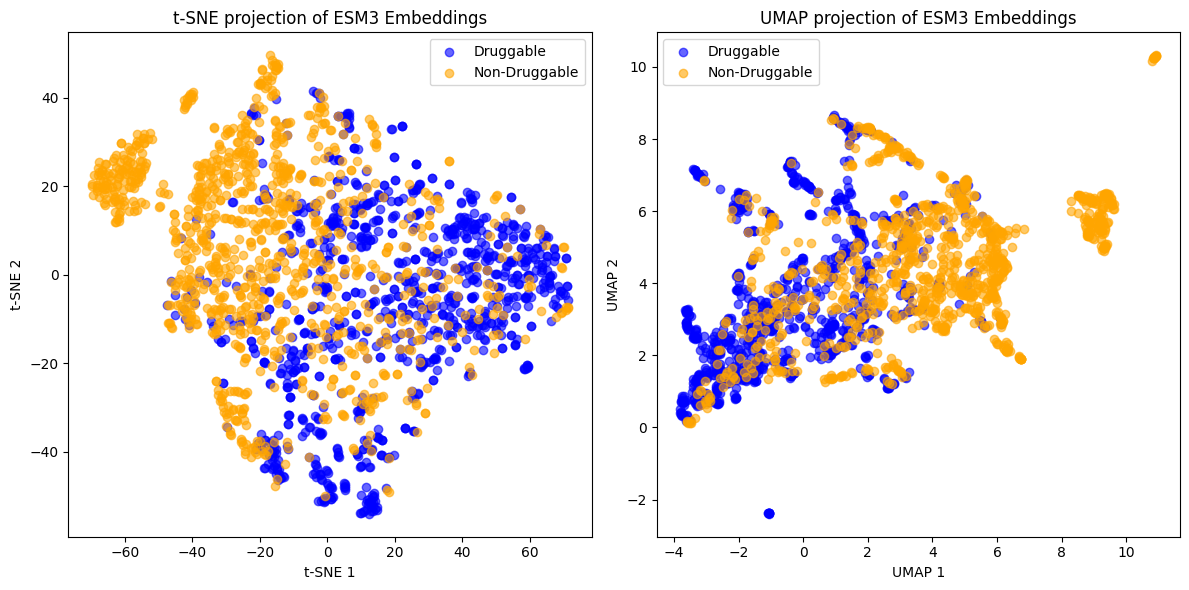

In [13]:
import umap
# print("Generating embeddings...")
# train_embeddings_list = embedding_generator.generate_embeddings(train_df['Sequence'].tolist())
# train_embeddings_df = embeddings_to_matrix(train_embeddings_list)

train_embeddings_df = pd.read_csv('data/drug_miner/train_embeddings_with_labels.csv')
test_embeddings_df = pd.read_csv('data/drug_miner/test_embeddings_with_labels.csv')

# Separate the embeddings and labels
embeddings = train_embeddings_df.iloc[:, :-1].values  # All columns except the last one
labels = train_embeddings_df['Druggable'].values  # The last column

# Perform t-SNE to reduce dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# Perform UMAP to reduce dimensionality to 2D
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_results = umap_model.fit_transform(embeddings)

# Plotting t-SNE results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(tsne_results[labels == 1, 0], tsne_results[labels == 1, 1], c='blue', label='Druggable', alpha=0.6)
plt.scatter(tsne_results[labels == 0, 0], tsne_results[labels == 0, 1], c='orange', label='Non-Druggable', alpha=0.6)
plt.title('t-SNE projection of ESM3 Embeddings')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()

# Plotting UMAP results
plt.subplot(1, 2, 2)
plt.scatter(umap_results[labels == 1, 0], umap_results[labels == 1, 1], c='blue', label='Druggable', alpha=0.6)
plt.scatter(umap_results[labels == 0, 0], umap_results[labels == 0, 1], c='orange', label='Non-Druggable', alpha=0.6)
plt.title('UMAP projection of ESM3 Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend()

plt.tight_layout()
plt.show()

The zero-shot t-SNE and UMAP projections of ESM3 embeddings reveal some local clustering by druggability class, particularly in the UMAP plot where non-druggable proteins form more distinct regions. While the separation is not sharp, these patterns suggest that ESM3 captures weak but biologically relevant signals related to druggability, even without supervision. The observed overlap highlights that druggability is a subtle and complex property, likely requiring a trained model to fully capture. Overall, these projections support the idea that ESM3 provides a meaningful representation space for downstream prediction tasks.

## Supervised classfication

As in the previous case study, we train a simple fully-connected classifier on top of the ESM3 embeddings. 

Training Drug Miner Classification Model...
Training samples: 2064, Test samples: 478
Unique training labels: [0 1]
Unique test labels: [0 1]


Training:   2%|▏         | 2/100 [00:00<00:06, 14.81it/s]

Epoch 0: Train Loss: 3.6688, Train Acc: 69.38%, Val Loss: 0.3742, Val Acc: 85.15%


Training:  14%|█▍        | 14/100 [00:00<00:05, 16.80it/s]

Epoch 10: Train Loss: 0.2882, Train Acc: 87.94%, Val Loss: 0.2460, Val Acc: 92.05%


...

Epoch 40: Train Loss: 0.2010, Train Acc: 91.91%, Val Loss: 0.2805, Val Acc: 90.17%


Training:  54%|█████▍    | 54/100 [00:03<00:02, 16.90it/s]

Epoch 50: Train Loss: 0.1638, Train Acc: 92.73%, Val Loss: 0.2989, Val Acc: 90.17%


Training:  54%|█████▍    | 54/100 [00:03<00:02, 15.68it/s]


Early stopping at epoch 54


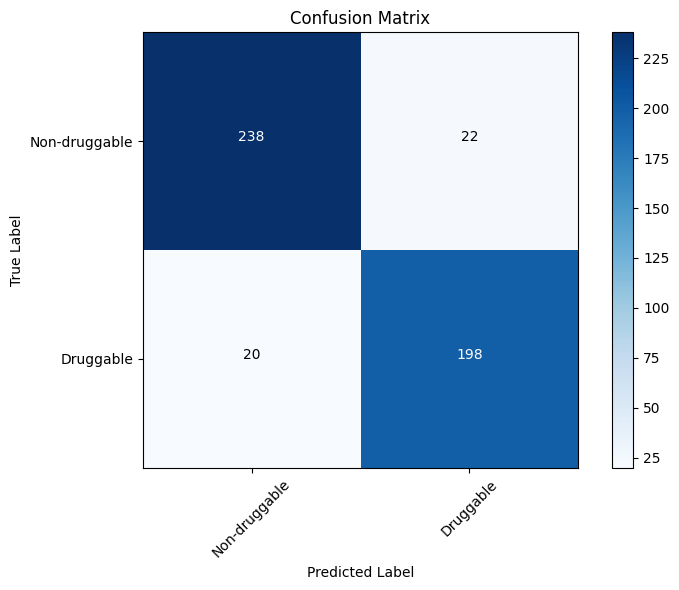


Drug Miner Classification Results:
Final Test Accuracy: 0.9121
Final Test F1 Score: 0.9122
Final Test AUC: 0.9613


In [14]:
from src.classification import DrugMinerClassifier

train_X = train_embeddings_df.iloc[:, :-1].values
train_y = train_embeddings_df.iloc[:, -1].values
test_X = test_embeddings_df.iloc[:, :-1].values  
test_y = test_embeddings_df.iloc[:, -1].values

# Initialize and train
drug_clf = DrugMinerClassifier(hidden_layers=[128, 64], dropout_rate=0.3)
metrics = drug_clf.train(
    train_embeddings=train_X,
    train_labels=train_y,  # 0/1 labels
    test_embeddings=test_X,
    test_labels=test_y,
    epochs=100
)


The confusion matrix shows that both druggable and non-druggable proteins are predicted with high confidence and minimal confusion. The errors are balanced and relatively few, indicating that the model has learned to distinguish between the two classes effectively.

## Generalization to Clinically Relevant Targets

To assess whether our model can generalize beyond the curated dataset, we tested it on two well-studied human proteins with distinct druggability profiles: **β-Catenin (P35222)** (left) and the **β2-Adrenergic Receptor (Q9BYZ0)** (right). These proteins were selected due to their contrasting drug discovery histories—while β2-Adrenergic Receptor is a prototypical drug target with multiple approved ligands, β-Catenin is widely regarded as a challenging target due to its lack of a well-defined ligandable pocket and extensive protein-protein interaction surface.

By evaluating the model's predictions on these sequences, we can probe whether the learned representation aligns with real-world pharmacological knowledge, and whether the classifier exhibits signs of biological grounding beyond training distribution. We checked that both sequences are not part of the training set.

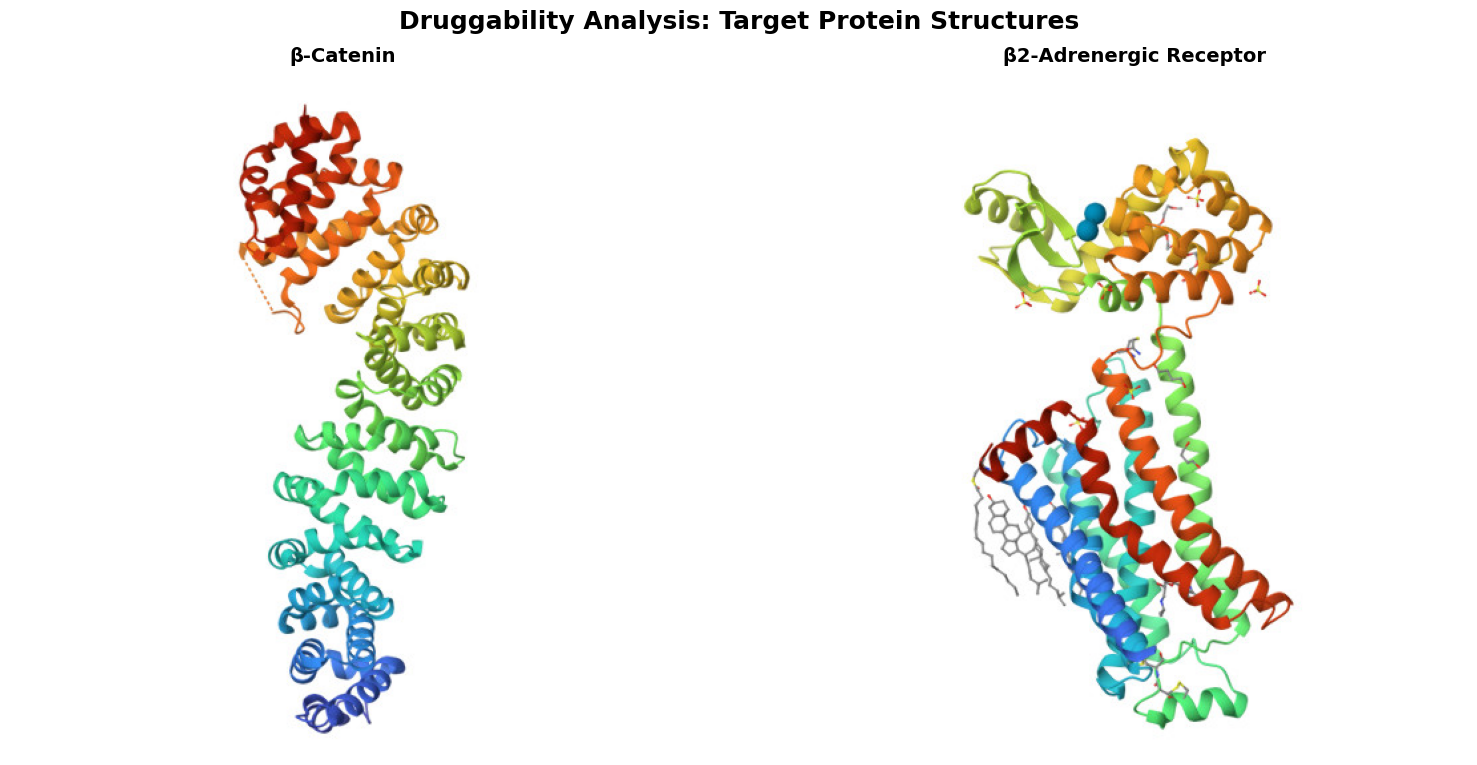

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_files = {
    'β-Catenin': 'data/drug_miner/β_Catenin.jpeg',
    'β2-Adrenergic Receptor': 'data/drug_miner/β2_Adrenergic_Receptor.jpeg'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, (protein_name, image_path) in enumerate(image_files.items()):
    try:
        img = mpimg.imread(image_path)
        axes[i].imshow(img)
        axes[i].set_title(f'{protein_name}', 
                         fontsize=14, fontweight='bold', pad=20)
        axes[i].axis('off')
        
        for spine in axes[i].spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor('gray')
            
    except FileNotFoundError:
        axes[i].text(0.5, 0.5, f'{protein_name}\nImage not found\n\nExpected: {image_path}', 
                    ha='center', va='center', transform=axes[i].transAxes, 
                    fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
        axes[i].set_title(f'{protein_name}\nProtein Structure', 
                         fontsize=14, fontweight='bold', pad=20)

fig.suptitle('Druggability Analysis: Target Protein Structures', 
             fontsize=18, fontweight='bold', y=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

In [16]:
from src.data_processing import check_sequence_location


positive_train_df = process_fasta_file('data/drug_miner/positive_train_sequence.fasta', druggable_value=1)
negative_train_df = process_fasta_file('data/drug_miner/negative_train_sequence.fasta', druggable_value=0)
train_df = pd.concat([positive_train_df, negative_train_df])

# KRAS sequence (human, wild-type)
beta_catenin = "MATQADLMELDMAMEPDRKAAVSHWQQQSYLDSGIHSGATTTAPSLSGKGNPEEEDVDTSQVLYEWEQGFSQSFTQEQVADIDGQYAMTRAQRVRAAMFPETLDEGMQIPSTQFDAAHPTNVQRLAEPSQMLKHAVVNLINYQDDAELATRAIPELTKLLNDEDQVVVNKAAVMVHQLSKKEASRHAIMRSPQMVSAIVRTMQNTNDVETARCTAGTLHNLSHHREGLLAIFKSGGIPALVKMLGSPVDSVLFYAITTLHNLLLHQEGAKMAVRLAGGLQKMVALLNKTNVKFLAITTDCLQILAYGNQESKLIILASGGPQALVNIMRTYTYEKLLWTTSRVLKVLSVCSSNKPAIVEAGGMQALGLHLTDPSQRLVQNCLWTLRNLSDAATKQEGMEGLLGTLVQLLGSDDINVVTCAAGILSNLTCNNYKNKMMVCQVGGIEALVRTVLRAGDREDITEPAICALRHLTSRHQEIEVTDAAVTLCAALFSDQGYQVLNGLDLTLQLQDTNSHLEVPQVTPLQSQRSVSTPITNSTTQGQPTMTPGNPQMLDFQQNRTSCLQVAQLTEKGLRLQPSASPSPIFQMTLTGGPRRPQQQINLSARRAPPIGSDKDQQTTNMGPPPTAHHQSGGTSSKQRLKSQTQVPIQAQTSNALNTTTYQAKQQNLPSRTKTSTIFPAPSLDNVKRLQNSQPLGSQSLPLGSQSPGQHQPNQRGVAPQQPKMQSMSLTAQSRHHRSTAPSTKTSLSEAEKRKMQHTGTYLSLDMHIRLQASQSLGPSKSLQLLPSLVLMSEDGSLGAPSQSRYEPLLPSTEPRHSLGQEQEKELVQELTQKTKL"

# Beta-2 adrenergic receptor sequence (human)
beta2_sequence = "VLVITAIAKFERLQTVTNYFITSLACADLVMGLAVVPFGAAHILMKMWTFGNFWCEFWTSIDVLCVTASIETLCVIAVDRYFAITSPFKYQSLLTKNKARVIILMVWIVSGLTSFLPIQMHWYRATHQEAINCYANETCCDFFTNQAYAIASSIVSFYVPLVIMVFVYSRVFQEAKRQLQKIDKSEGRFHVQNLSQVEQDGRTGHGLRRSSKFCLKEHKALKTLGIIMGTFTLCWLPFFIVNIVHVIQDNLIRKEVYILLNWIGYVNSGFNPLIY"

# Function to predict druggability
def predict_druggability(sequence, name):
    if check_sequence_location(sequence, train_df):
        print(f"{name}: Found in training set (cannot predict)")
        return None
    
    # Generate embedding and predict
    embeddings = embedding_generator.generate_embeddings([sequence])
    embedding_array = np.array(embeddings[0]).reshape(1, -1)
    
    probability = drug_clf.predict_proba(embedding_array)[0][1]
    prediction = "Druggable" if probability > 0.5 else "Non-druggable"
    
    print(f"{name}: {prediction} (confidence: {probability:.3f})")
    return probability

# Make predictions
kras_prob = predict_druggability(beta_catenin, "β-Catenin")
beta2_prob = predict_druggability(beta2_sequence, "Beta-2 Adrenergic Receptor")

Generating embeddings: 100%|██████████| 1/1 [00:08<00:00,  8.44s/it]


β-Catenin: Non-druggable (confidence: 0.128)


Generating embeddings: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]

Beta-2 Adrenergic Receptor: Druggable (confidence: 0.961)


The model predicted **non-druggable for β-Catenin**, with a probability of 0.128, and **druggable for β2-Adrenergic Receptor**, with a probability of 0.99. These predictions align with domain knowledge and reinforce the idea that the classifier, although trained on a benchmark dataset, is capable of making biologically plausible few-shot generalizations to therapeutically important proteins.

## Conclusion

This notebook explored how ESM3 embeddings can be used across diverse protein analysis tasks. We first visualized the embeddings in a zero-shot manner, showing that they reflect meaningful biological structure, separating proteins by function and taxonomy without supervision. We then trained lightweight classifiers on frozen embeddings and demonstrated strong performance in both kingdom classification and druggability prediction. Finally, we tested the model’s generalization to clinically relevant targets, confirming its ability to make biologically plausible predictions. These results highlight ESM3’s strength as a foundation for both exploratory and predictive protein modeling.